# Hotel Reviews - LDA Topic Modeling

This notebook implements Latent Dirichlet Allocation (LDA) topic modeling on hotel reviews.

**Goals:**
1. Load preprocessed review data
2. Create document-term matrices
3. Determine optimal number of topics using coherence scores
4. Train LDA models for negative and positive reviews
5. Extract and interpret topics
6. Visualize topics with word clouds and charts
7. Save models and results

In [1]:
# Imports
import re
import pandas as pd
import numpy as np
import pickle
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# LDA and topic modeling
from gensim import corpora
from gensim.models import LdaMulticore, CoherenceModel
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-whitegrid')

%matplotlib inline

# Set random seed for reproducibility
np.random.seed(42)

print("Imports successful!")

Imports successful!


## 1. Load Preprocessed Data

In [2]:
# Option 1: Load sample data (fast for testing)
USE_SAMPLE = True  # Set to False to use full dataset

if USE_SAMPLE:
    print("Loading SAMPLE datasets (50K reviews each)...")
    df_neg = pd.read_parquet('data/negative_reviews_sample.parquet')
    df_pos = pd.read_parquet('data/positive_reviews_sample.parquet')
else:
    print("Loading FULL datasets...")
    df_neg = pd.read_parquet('data/negative_reviews_processed.parquet')
    df_pos = pd.read_parquet('data/positive_reviews_processed.parquet')

print(f"\nNegative reviews: {len(df_neg):,}")
print(f"Positive reviews: {len(df_pos):,}")

df_neg.head()

Loading SAMPLE datasets (50K reviews each)...

Negative reviews: 50,000
Positive reviews: 50,000


,Hotel_Name,Reviewer_Nationality,Reviewer_Score,Review_Date,Average_Score,text_original,text_cleaned,word_count_original,word_count_cleaned,sentiment
0,Park Grand Paddington Court,United States of America,9.6,4/16/2016,8.1,my us wall outlet power in the room was not working so i bought an adaptor at nearby store for 1...,wall outlet power not work buy adaptor nearby store,22,9,negative
1,Hotel Capricorno,United States of America,7.1,4/21/2016,9.1,air conditioning was broke and being on floor 1 we had to open windows street noise and alley wa...,air conditioning broke floor open windows street noise alley noisy wifi free spotty,25,13,negative
2,Hotel Capitol Milano,India,5.4,11/9/2015,8.3,the bathroom space was very much inadequate couldnt even turn around in the bathroom while bathi...,bathroom space much inadequate could not even turn around bathroom bathing size also small breat...,41,24,negative
3,Best Western Plus Hotel Felice Casati,Russia,7.1,8/1/2017,8.4,rooms did not really feel too comfy but good enough to sleep maybe i am being picky everything w...,not really feel comfy good enough sleep maybe picky everything fine give price good option low p...,62,30,negative
4,Majestic Hotel Spa Barcelona GL,Sweden,8.8,9/27/2016,8.9,more care could be taken by the interior decorator e g somewhere to put the soap in the shower a...,care could take interior decorator somewhere put soap shower reading light every bed wall door b...,39,20,negative


## 2. Prepare Data for LDA

In [3]:
def prepare_lda_data(df, text_column='text_cleaned'):
    """
    Prepare data for LDA modeling.
    
    Args:
        df: DataFrame with preprocessed reviews
        text_column: Column name with cleaned text
        
    Returns:
        texts: List of tokenized documents
        dictionary: Gensim dictionary
        corpus: Gensim corpus (bag of words)
    """
    # Get cleaned text
    documents = df[text_column].tolist()
    
    # Tokenize (split into words)
    texts = [doc.split() for doc in documents]
    
    # Create dictionary
    dictionary = corpora.Dictionary(texts)
    
    # Filter extremes
    dictionary.filter_extremes(
        no_below=5,      # Minimum 5 documents
        no_above=0.7,    # Maximum 70% of documents
        keep_n=5000      # Keep top 5000 tokens
    )
    
    # Create corpus (bag of words)
    corpus = [dictionary.doc2bow(text) for text in texts]
    
    print(f"Dictionary size: {len(dictionary)}")
    print(f"Corpus size: {len(corpus)} documents")
    
    return texts, dictionary, corpus

print("Preparing negative reviews...")
texts_neg, dictionary_neg, corpus_neg = prepare_lda_data(df_neg)

print("\nPreparing positive reviews...")
texts_pos, dictionary_pos, corpus_pos = prepare_lda_data(df_pos)

Preparing negative reviews...
Dictionary size: 5000
Corpus size: 50000 documents

Preparing positive reviews...
Dictionary size: 4152
Corpus size: 50000 documents


## 3. Determine Optimal Number of Topics

We'll test different numbers of topics and calculate coherence scores to find the optimal value.

In [4]:
def compute_coherence_values(dictionary, corpus, texts, limit=30, start=5, step=5):
    """
    Compute coherence scores for different numbers of topics.
    
    Args:
        dictionary: Gensim dictionary
        corpus: Gensim corpus
        texts: List of tokenized documents
        limit: Maximum number of topics to test
        start: Minimum number of topics to test
        step: Step size
        
    Returns:
        model_list: List of LDA models
        coherence_values: List of coherence scores
    """
    coherence_values = []
    model_list = []
    
    for num_topics in tqdm(range(start, limit + 1, step), desc="Testing topic counts"):
        # Train model
        model = LdaMulticore(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            chunksize=2000,
            passes=10,
            iterations=100,
            per_word_topics=True,
            workers=4
        )
        
        model_list.append(model)
        
        # Calculate coherence
        coherence_model = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )
        
        coherence_values.append(coherence_model.get_coherence())
    
    return model_list, coherence_values

# Note: This can take a while! Testing 5, 10, 15, 20, 25 topics
print("Testing different numbers of topics for NEGATIVE reviews...")
print("(This may take 10-15 minutes)\n")

models_neg, coherence_neg = compute_coherence_values(
    dictionary_neg, 
    corpus_neg, 
    texts_neg,
    limit=25,
    start=5,
    step=5
)

print("\nTesting different numbers of topics for POSITIVE reviews...")
print("(This may take 10-15 minutes)\n")

models_pos, coherence_pos = compute_coherence_values(
    dictionary_pos,
    corpus_pos,
    texts_pos,
    limit=25,
    start=5,
    step=5
)

Testing different numbers of topics for NEGATIVE reviews...
(This may take 10-15 minutes)



Testing topic counts: 100%|██████████| 5/5 [02:05<00:00, 25.08s/it]



Testing different numbers of topics for POSITIVE reviews...
(This may take 10-15 minutes)



Testing topic counts: 100%|██████████| 5/5 [02:16<00:00, 27.34s/it]


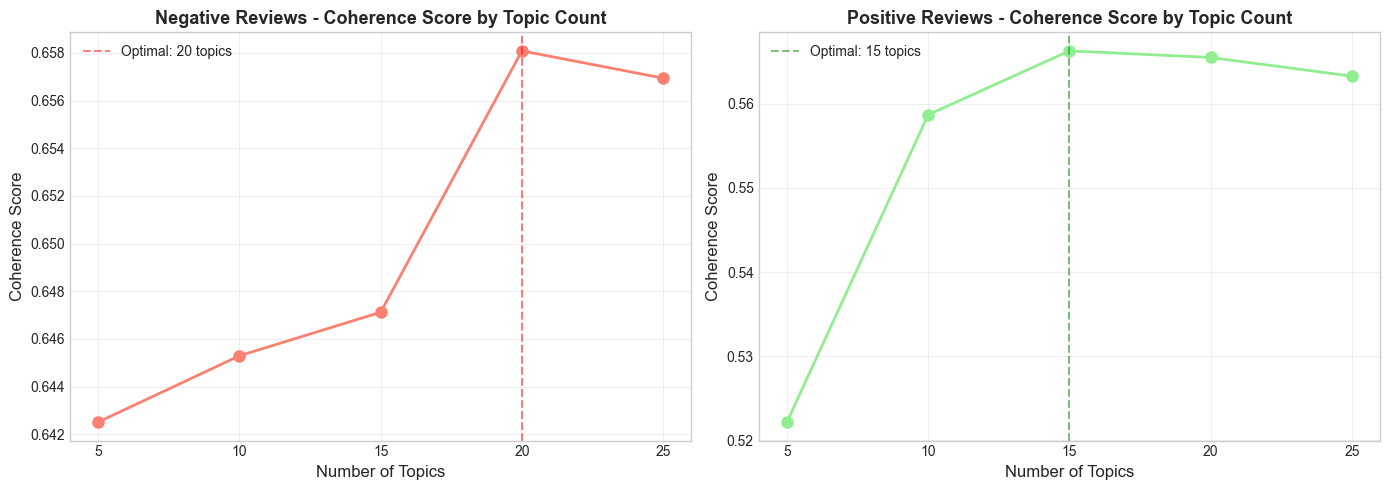


Optimal number of topics:
  Negative reviews: 20 (coherence: 0.6581)
  Positive reviews: 15 (coherence: 0.5663)


In [5]:
# Plot coherence scores
topic_nums = list(range(5, 26, 5))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Negative reviews
ax1 = axes[0]
ax1.plot(topic_nums, coherence_neg, 'o-', color='salmon', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Topics', fontsize=12)
ax1.set_ylabel('Coherence Score', fontsize=12)
ax1.set_title('Negative Reviews - Coherence Score by Topic Count', fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.set_xticks(topic_nums)

# Mark optimal
optimal_neg = topic_nums[np.argmax(coherence_neg)]
ax1.axvline(optimal_neg, color='red', linestyle='--', alpha=0.5, 
            label=f'Optimal: {optimal_neg} topics')
ax1.legend()

# Positive reviews
ax2 = axes[1]
ax2.plot(topic_nums, coherence_pos, 'o-', color='lightgreen', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Topics', fontsize=12)
ax2.set_ylabel('Coherence Score', fontsize=12)
ax2.set_title('Positive Reviews - Coherence Score by Topic Count', fontsize=13, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.set_xticks(topic_nums)

# Mark optimal
optimal_pos = topic_nums[np.argmax(coherence_pos)]
ax2.axvline(optimal_pos, color='green', linestyle='--', alpha=0.5,
            label=f'Optimal: {optimal_pos} topics')
ax2.legend()

plt.tight_layout()
plt.savefig('outputs/visualizations/topic_distributions/lda_coherence_scores.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOptimal number of topics:")
print(f"  Negative reviews: {optimal_neg} (coherence: {max(coherence_neg):.4f})")
print(f"  Positive reviews: {optimal_pos} (coherence: {max(coherence_pos):.4f})")

## 4. Train Final LDA Models

Using the optimal number of topics determined above.

In [6]:
# Use the optimal models or retrain with a specific number
# Option 1: Use models from coherence testing
lda_neg = models_neg[np.argmax(coherence_neg)]
lda_pos = models_pos[np.argmax(coherence_pos)]

# Option 2: Train new models with specific number (uncomment to use)
# NUM_TOPICS = 10
# print(f"Training LDA model for negative reviews with {NUM_TOPICS} topics...")
# lda_neg = LdaMulticore(
#     corpus=corpus_neg,
#     id2word=dictionary_neg,
#     num_topics=NUM_TOPICS,
#     random_state=42,
#     chunksize=2000,
#     passes=10,
#     iterations=100,
#     per_word_topics=True,
#     workers=4
# )

# print(f"Training LDA model for positive reviews with {NUM_TOPICS} topics...")
# lda_pos = LdaMulticore(
#     corpus=corpus_pos,
#     id2word=dictionary_pos,
#     num_topics=NUM_TOPICS,
#     random_state=42,
#     chunksize=2000,
#     passes=10,
#     iterations=100,
#     per_word_topics=True,
#     workers=4
# )

print(f"\n✅ Final models trained!")
print(f"  Negative reviews: {lda_neg.num_topics} topics")
print(f"  Positive reviews: {lda_pos.num_topics} topics")


✅ Final models trained!
  Negative reviews: 20 topics
  Positive reviews: 15 topics


## 5. Extract and Display Topics

In [7]:
def display_topics(model, num_words=15):
    """
    Display topics with their top words.
    
    Args:
        model: Trained LDA model
        num_words: Number of top words to show per topic
        
    Returns:
        topics_df: DataFrame with topic information
    """
    topics = []
    
    for idx in range(model.num_topics):
        topic_words = model.show_topic(idx, topn=num_words)
        words = [word for word, prob in topic_words]
        probs = [prob for word, prob in topic_words]
        
        topics.append({
            'Topic': f'Topic {idx}',
            'Top Words': ', '.join(words[:10]),
            'All Words': topic_words
        })
    
    return pd.DataFrame(topics)

print("="*100)
print("NEGATIVE REVIEW TOPICS")
print("="*100)
topics_neg_df = display_topics(lda_neg, num_words=15)
for idx, row in topics_neg_df.iterrows():
    print(f"\n{row['Topic']}:")
    print(f"  {row['Top Words']}")

print("\n" + "="*100)
print("POSITIVE REVIEW TOPICS")
print("="*100)
topics_pos_df = display_topics(lda_pos, num_words=15)
for idx, row in topics_pos_df.iterrows():
    print(f"\n{row['Topic']}:")
    print(f"  {row['Top Words']}")

NEGATIVE REVIEW TOPICS

Topic 0:
  not, star, poor, money, value, standard, quality, small, good, breakfast

Topic 1:
  bar, restaurant, service, drink, food, area, mini, expensive, bit, lounge

Topic 2:
  breakfast, not, food, good, expensive, include, egg, could, buffet, poor

Topic 3:
  location, far, not, walk, city, station, bit, get, taxi, good

Topic 4:
  wifi, not, work, slow, free, internet, floor, access, time, connection

Topic 5:
  would, iron, staff, good, experience, hair, nice, not, plug, like

Topic 6:
  old, not, need, look, clean, nothing, bathroom, dirty, carpet, like

Topic 7:
  check, not, tell, pay, ask, get, day, take, book, say

Topic 8:
  parking, not, car, day, park, time, leave, check, come, clean

Topic 9:
  bed, small, double, not, single, two, bit, comfortable, little, uncomfortable

Topic 10:
  door, hear, next, could, noise, not, wall, noisy, people, sound

Topic 11:
  small, view, tiny, not, book, upgrade, one, window, space, size

Topic 12:
  air, not,

## 6. Assign Topic Labels (Manual Interpretation)

Based on the top words, assign meaningful labels to each topic.

In [8]:
# TODO: Update these labels based on the actual topics above
# Example labels (you'll need to customize based on your results)

topic_labels_neg = {
    0: "Room Size and Space",
    1: "Breakfast Quality",
    2: "Noise Issues",
    3: "Staff Service",
    4: "Bathroom and Shower",
    5: "Location and Transport",
    6: "Cleanliness Issues",
    7: "Price and Value",
    8: "Facilities and Amenities",
    9: "Check-in and Reception"
}

topic_labels_pos = {
    0: "Location and Accessibility",
    1: "Staff Friendliness",
    2: "Room Comfort",
    3: "Cleanliness",
    4: "Breakfast Quality",
    5: "Facilities and Amenities",
    6: "Value for Money",
    7: "View and Atmosphere",
    8: "Modern and Well-equipped",
    9: "Overall Experience"
}

print("Topic labels assigned!")
print("\nNegative Review Topics:")
for idx, label in topic_labels_neg.items():
    if idx < lda_neg.num_topics:
        print(f"  Topic {idx}: {label}")

print("\nPositive Review Topics:")
for idx, label in topic_labels_pos.items():
    if idx < lda_pos.num_topics:
        print(f"  Topic {idx}: {label}")


Topic labels assigned!

Negative Review Topics:
  Topic 0: Room Size and Space
  Topic 1: Breakfast Quality
  Topic 2: Noise Issues
  Topic 3: Staff Service
  Topic 4: Bathroom and Shower
  Topic 5: Location and Transport
  Topic 6: Cleanliness Issues
  Topic 7: Price and Value
  Topic 8: Facilities and Amenities
  Topic 9: Check-in and Reception

Positive Review Topics:
  Topic 0: Location and Accessibility
  Topic 1: Staff Friendliness
  Topic 2: Room Comfort
  Topic 3: Cleanliness
  Topic 4: Breakfast Quality
  Topic 5: Facilities and Amenities
  Topic 6: Value for Money
  Topic 7: View and Atmosphere
  Topic 8: Modern and Well-equipped
  Topic 9: Overall Experience


## 7. Visualize Topics - Word Clouds

Creating word clouds for negative reviews...


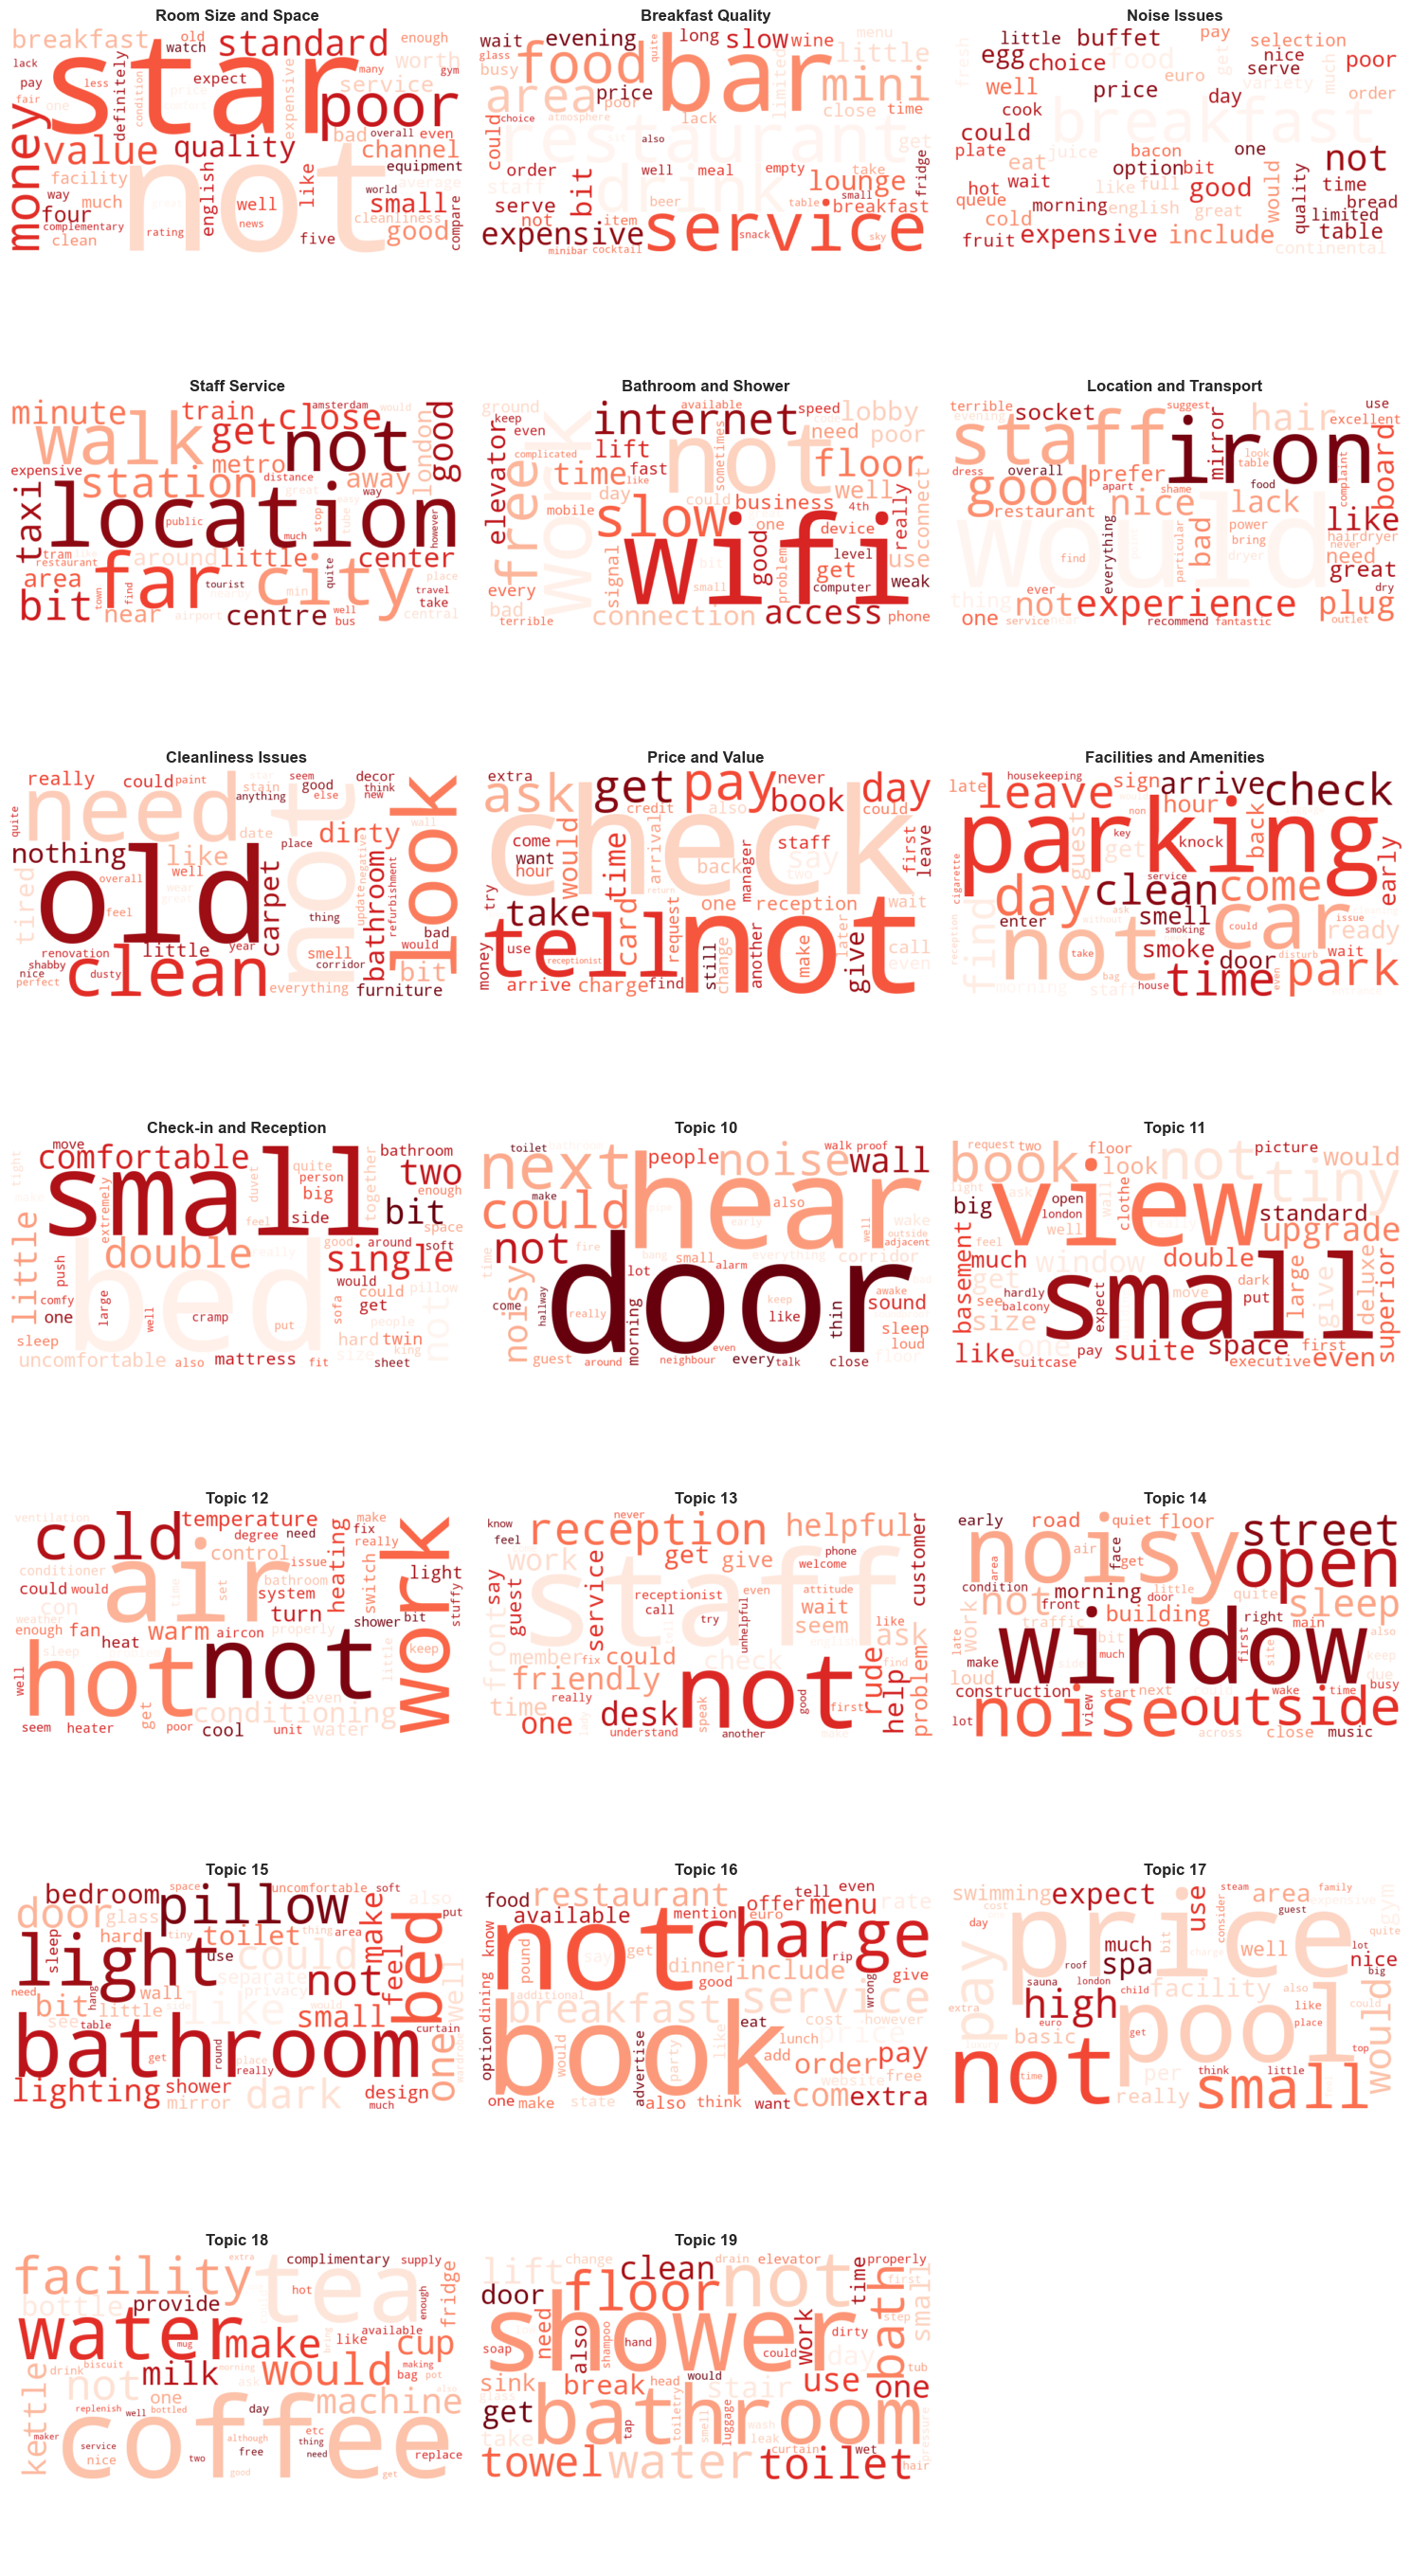


Creating word clouds for positive reviews...


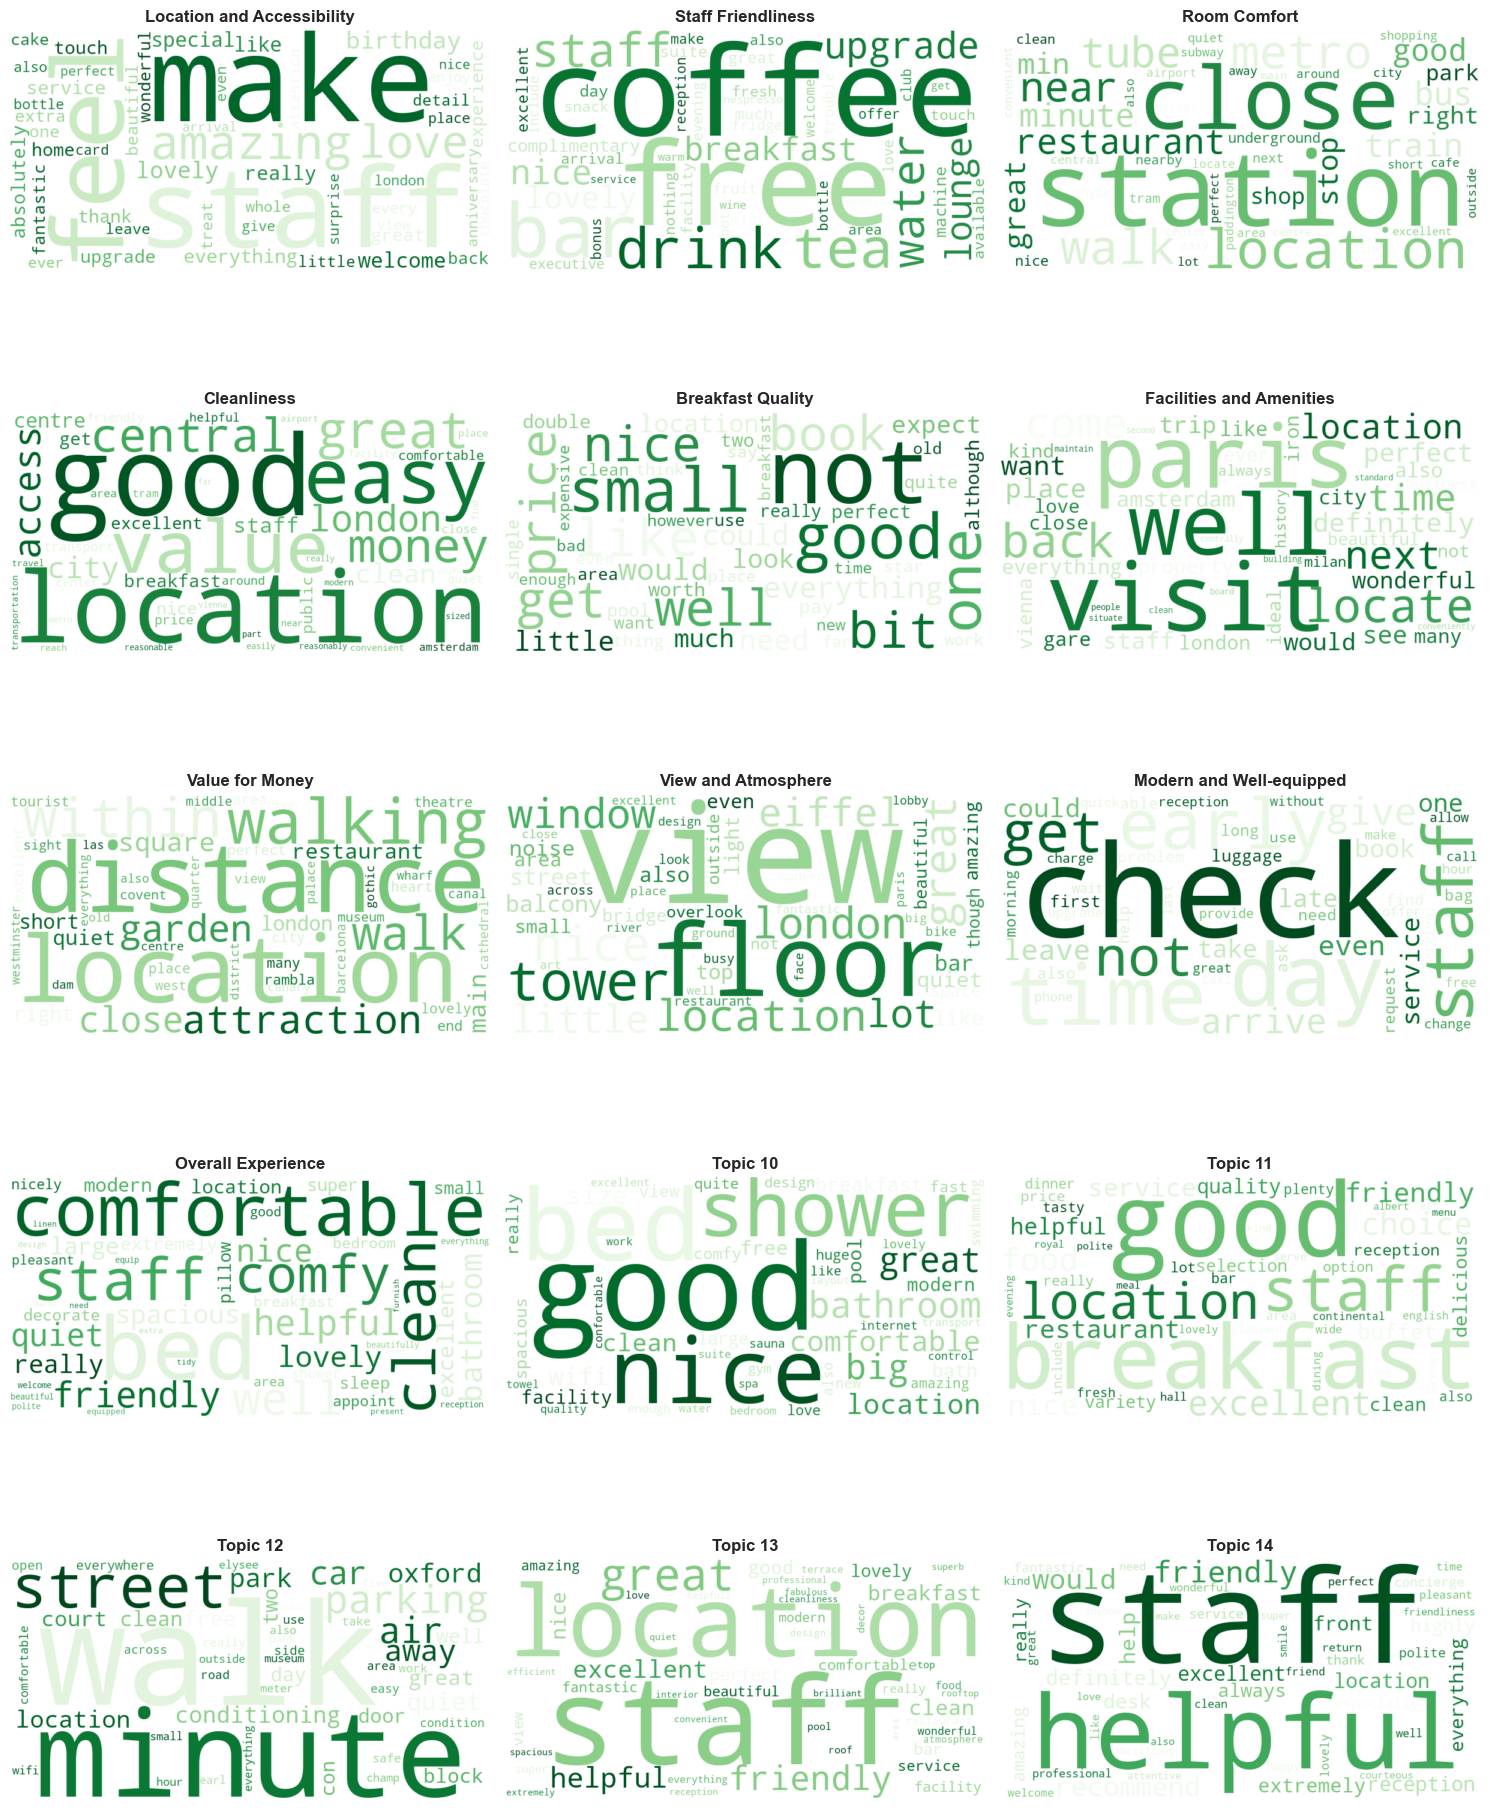

In [9]:
def create_topic_wordclouds(model, topic_labels, sentiment="negative", num_topics=None):
    """
    Create word clouds for each topic.
    """
    if num_topics is None:
        num_topics = model.num_topics

    colormap = "Reds" if sentiment == "negative" else "Greens"

    cols = 3
    rows = int(np.ceil(num_topics / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
    axes = axes.flatten() if num_topics > 1 else [axes]

    for idx in range(num_topics):
        topic_words = dict(model.show_topic(idx, topn=50))

        wc = WordCloud(
            width=800, height=400,
            background_color="white",
            colormap=colormap,
            relative_scaling=0.5,
            min_font_size=10
        ).generate_from_frequencies(topic_words)

        axes[idx].imshow(wc, interpolation="bilinear")
        axes[idx].axis("off")

        label = topic_labels.get(idx, f"Topic {idx}")
        axes[idx].set_title(f"{label}", fontsize=12, fontweight="bold")

        # Sanitize label for filename - remove any special chars
        safe_label = re.sub(r"[^\w\s-]", "", label).replace(" ", "_").lower()

        individual_fig, ax = plt.subplots(figsize=(10, 5))
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title(f"{sentiment.capitalize()} Reviews - {label}",
                    fontsize=14, fontweight="bold")
        individual_fig.tight_layout()
        individual_fig.savefig(
            f"outputs/visualizations/wordclouds/lda_{sentiment}_topic{idx}_{safe_label}.png",
            dpi=150, bbox_inches="tight"
        )
        plt.close(individual_fig)

    for idx in range(num_topics, len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    plt.savefig(
        f"outputs/visualizations/wordclouds/lda_{sentiment}_all_topics.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show()

print("Creating word clouds for negative reviews...")
create_topic_wordclouds(lda_neg, topic_labels_neg, sentiment="negative")

print("\nCreating word clouds for positive reviews...")
create_topic_wordclouds(lda_pos, topic_labels_pos, sentiment="positive")


## 8. Visualize Topic Distributions

In [10]:
def get_dominant_topics(model, corpus):
    """
    Get the dominant topic for each document.
    
    Args:
        model: Trained LDA model
        corpus: Gensim corpus
        
    Returns:
        List of dominant topic IDs
    """
    dominant_topics = []
    
    for doc_bow in corpus:
        topic_probs = model.get_document_topics(doc_bow)
        if topic_probs:
            dominant_topic = max(topic_probs, key=lambda x: x[1])[0]
            dominant_topics.append(dominant_topic)
        else:
            dominant_topics.append(-1)
    
    return dominant_topics

# Get dominant topics
print("Calculating dominant topics for each review...")
dominant_neg = get_dominant_topics(lda_neg, corpus_neg)
dominant_pos = get_dominant_topics(lda_pos, corpus_pos)

# Add to dataframes
df_neg['dominant_topic'] = dominant_neg
df_pos['dominant_topic'] = dominant_pos

# Count topic distributions
topic_dist_neg = df_neg['dominant_topic'].value_counts().sort_index()
topic_dist_pos = df_pos['dominant_topic'].value_counts().sort_index()

print("\nNegative Reviews - Topic Distribution:")
print(topic_dist_neg)
print("\nPositive Reviews - Topic Distribution:")
print(topic_dist_pos)

Calculating dominant topics for each review...

Negative Reviews - Topic Distribution:
dominant_topic
0     1370
1     2024
2     3602
3     3067
4     1361
5      898
6     3415
7     5249
8     2282
9     3005
10    2021
11    2357
12    2184
13    3400
14    2394
15    2145
16    1616
17    2388
18    1476
19    3746
Name: count, dtype: int64

Positive Reviews - Topic Distribution:
dominant_topic
0      3100
1      2155
2      5607
3      3157
4      2779
5      1080
6      1275
7      1352
8      2419
9      4651
10     3007
11     3973
12      870
13    10150
14     4425
Name: count, dtype: int64


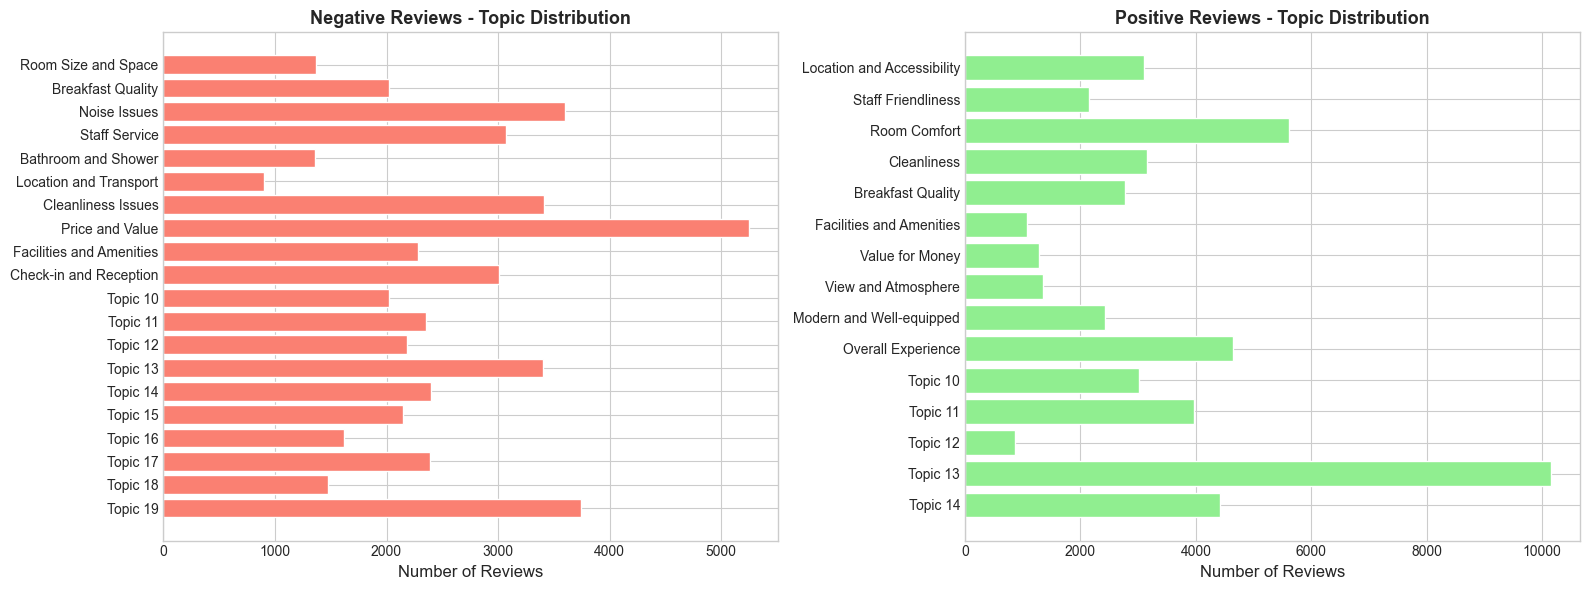

In [11]:
# Visualize topic distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Negative reviews
ax1 = axes[0]
labels_neg = [topic_labels_neg.get(i, f'Topic {i}') for i in topic_dist_neg.index]
ax1.barh(labels_neg, topic_dist_neg.values, color='salmon', edgecolor='white')
ax1.set_xlabel('Number of Reviews', fontsize=12)
ax1.set_title('Negative Reviews - Topic Distribution', fontsize=13, fontweight='bold')
ax1.invert_yaxis()

# Positive reviews
ax2 = axes[1]
labels_pos = [topic_labels_pos.get(i, f'Topic {i}') for i in topic_dist_pos.index]
ax2.barh(labels_pos, topic_dist_pos.values, color='lightgreen', edgecolor='white')
ax2.set_xlabel('Number of Reviews', fontsize=12)
ax2.set_title('Positive Reviews - Topic Distribution', fontsize=13, fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/visualizations/topic_distributions/lda_topic_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 9. Interactive Visualization with pyLDAvis

In [12]:
# Prepare visualization for negative reviews
print("Preparing interactive visualization for negative reviews...")
vis_neg = gensimvis.prepare(lda_neg, corpus_neg, dictionary_neg, sort_topics=False)
pyLDAvis.save_html(vis_neg, 'outputs/visualizations/intertopic_distance/lda_negative_interactive.html')
print("  Saved to: outputs/visualizations/intertopic_distance/lda_negative_interactive.html")

# Display in notebook
pyLDAvis.display(vis_neg)

Preparing interactive visualization for negative reviews...
  Saved to: outputs/visualizations/intertopic_distance/lda_negative_interactive.html


In [13]:
# Prepare visualization for positive reviews
print("Preparing interactive visualization for positive reviews...")
vis_pos = gensimvis.prepare(lda_pos, corpus_pos, dictionary_pos, sort_topics=False)
pyLDAvis.save_html(vis_pos, 'outputs/visualizations/intertopic_distance/lda_positive_interactive.html')
print("  Saved to: outputs/visualizations/intertopic_distance/lda_positive_interactive.html")

# Display in notebook
pyLDAvis.display(vis_pos)

Preparing interactive visualization for positive reviews...
  Saved to: outputs/visualizations/intertopic_distance/lda_positive_interactive.html


## 10. Save Models and Results

In [14]:
# Save LDA models
print("Saving LDA models...")
lda_neg.save('outputs/models/lda_negative.model')
lda_pos.save('outputs/models/lda_positive.model')

# Save dictionaries
dictionary_neg.save('outputs/preprocessing/dictionary_negative.dict')
dictionary_pos.save('outputs/preprocessing/dictionary_positive.dict')

# Save topic labels
with open('outputs/models/topic_labels_negative.pkl', 'wb') as f:
    pickle.dump(topic_labels_neg, f)

with open('outputs/models/topic_labels_positive.pkl', 'wb') as f:
    pickle.dump(topic_labels_pos, f)

print("\n✅ Models saved successfully!")

Saving LDA models...

✅ Models saved successfully!


In [15]:
# Export topic information to CSV
print("Exporting topic information...")

# Negative topics
topics_neg_export = []
for idx in range(lda_neg.num_topics):
    words = lda_neg.show_topic(idx, topn=20)
    topics_neg_export.append({
        'Topic_ID': idx,
        'Label': topic_labels_neg.get(idx, f'Topic {idx}'),
        'Top_Words': ', '.join([w for w, p in words[:10]]),
        'Word_Probabilities': str(words),
        'Document_Count': topic_dist_neg.get(idx, 0)
    })

pd.DataFrame(topics_neg_export).to_csv(
    'outputs/topics/lda_negative_topics.csv',
    index=False
)

# Positive topics
topics_pos_export = []
for idx in range(lda_pos.num_topics):
    words = lda_pos.show_topic(idx, topn=20)
    topics_pos_export.append({
        'Topic_ID': idx,
        'Label': topic_labels_pos.get(idx, f'Topic {idx}'),
        'Top_Words': ', '.join([w for w, p in words[:10]]),
        'Word_Probabilities': str(words),
        'Document_Count': topic_dist_pos.get(idx, 0)
    })

pd.DataFrame(topics_pos_export).to_csv(
    'outputs/topics/lda_positive_topics.csv',
    index=False
)

print("\n✅ Topic information exported!")
print("  - outputs/topics/lda_negative_topics.csv")
print("  - outputs/topics/lda_positive_topics.csv")

Exporting topic information...

✅ Topic information exported!
  - outputs/topics/lda_negative_topics.csv
  - outputs/topics/lda_positive_topics.csv


## 11. Summary and Next Steps

In [16]:
print("="*80)
print("LDA TOPIC MODELING SUMMARY")
print("="*80)
print(f"\nNegative Reviews:")
print(f"  - Documents analyzed: {len(corpus_neg):,}")
print(f"  - Number of topics: {lda_neg.num_topics}")
print(f"  - Coherence score: {coherence_neg[topic_nums.index(lda_neg.num_topics)] if lda_neg.num_topics in topic_nums else 'N/A'}")
print(f"  - Vocabulary size: {len(dictionary_neg)}")

print(f"\nPositive Reviews:")
print(f"  - Documents analyzed: {len(corpus_pos):,}")
print(f"  - Number of topics: {lda_pos.num_topics}")
print(f"  - Coherence score: {coherence_pos[topic_nums.index(lda_pos.num_topics)] if lda_pos.num_topics in topic_nums else 'N/A'}")
print(f"  - Vocabulary size: {len(dictionary_pos)}")

print(f"\nOutput Files:")
print(f"  - Models: outputs/models/lda_negative.model, lda_positive.model")
print(f"  - Topics: outputs/topics/lda_*_topics.csv")
print(f"  - Visualizations: outputs/visualizations/")
print(f"    * Word clouds: {lda_neg.num_topics + lda_pos.num_topics} files")
print(f"    * Interactive HTML: 2 files")

print("\n" + "="*80)
print("✅ LDA Topic Modeling Complete!")
print("="*80)
print("\nNext steps:")
print("  1. Review topic labels and refine if needed")
print("  2. Run 04_topic_modeling_bertopic.ipynb for BERTopic comparison")
print("  3. Compare LDA vs BERTopic results")
print("  4. Generate business insights from topics")

LDA TOPIC MODELING SUMMARY

Negative Reviews:
  - Documents analyzed: 50,000
  - Number of topics: 20
  - Coherence score: 0.6580834905779304
  - Vocabulary size: 5000

Positive Reviews:
  - Documents analyzed: 50,000
  - Number of topics: 15
  - Coherence score: 0.5662914054665917
  - Vocabulary size: 4152

Output Files:
  - Models: outputs/models/lda_negative.model, lda_positive.model
  - Topics: outputs/topics/lda_*_topics.csv
  - Visualizations: outputs/visualizations/
    * Word clouds: 35 files
    * Interactive HTML: 2 files

✅ LDA Topic Modeling Complete!

Next steps:
  1. Review topic labels and refine if needed
  2. Run 04_topic_modeling_bertopic.ipynb for BERTopic comparison
  3. Compare LDA vs BERTopic results
  4. Generate business insights from topics
